# Toxicity / Hate-Speech Detection — Cleaned Notebook

This notebook builds a **binary toxic-comment detector** from the Jigsaw Toxic Comment Classification dataset.

> Important terminology: the original Jigsaw dataset contains six toxicity-related labels: `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, and `identity_hate`.  
> This notebook follows the project's existing approach of creating one binary target: **1 if any of those labels is 1, otherwise 0**. Therefore, the resulting model is technically a **toxicity detector**, not a pure hate-speech detector.

In [1]:
# Install only what is needed.
!pip -q install nltk scikit-learn joblib seaborn

In [2]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
RANDOM_STATE = 42

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 1. Load the Jigsaw files

If you are using Google Colab, upload the ZIP containing `train.csv`, `test.csv`, and `test_labels.csv`, then extract it.

In [3]:
# Google Colab upload
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [4]:
import zipfile

zip_files = [f for f in os.listdir(".") if f.lower().endswith(".zip")]
if zip_files:
    with zipfile.ZipFile(zip_files[0], "r") as z:
        z.extractall(".")
    print("Extracted:", zip_files[0])

print(os.listdir("."))

Extracted: archive (1).zip
['.config', 'sample_submission.csv', 'test_labels.csv', 'test.csv', 'archive (1).zip', 'train.csv', 'sample_data']


In [5]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
test_labels = pd.read_csv("test_labels.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Test labels shape:", test_labels.shape)

display(train.head())

Train shape: (159571, 8)
Test shape: (153164, 2)
Test labels shape: (153164, 7)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
print("Missing values:")
display(train.isnull().sum())

Missing values:


,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


## 2. Create the binary target

The original notebook used the maximum of all six Jigsaw labels. That is retained here so the corrected notebook remains comparable with the existing project.

A comment becomes `1` when **any** of the six toxicity labels is present.

In [7]:
label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

train["target"] = train[label_cols].max(axis=1).astype(int)

print(train["target"].value_counts())
print(train["target"].value_counts(normalize=True).rename("proportion"))

target
0    143346
1     16225
Name: count, dtype: int64
target
0    0.898321
1    0.101679
Name: proportion, dtype: float64


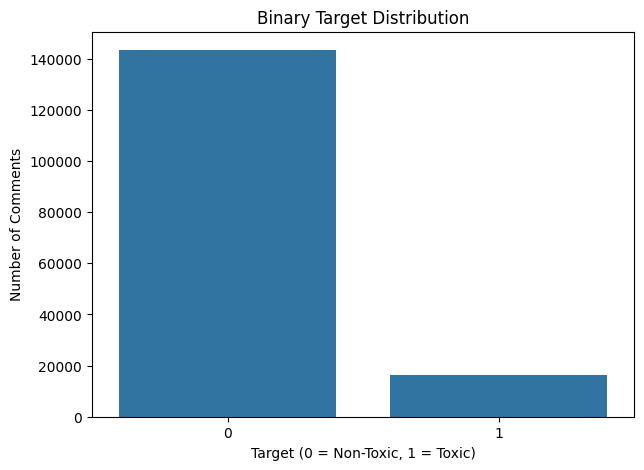

In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(data=train, x="target")
plt.title("Binary Target Distribution")
plt.xlabel("Target (0 = Non-Toxic, 1 = Toxic)")
plt.ylabel("Number of Comments")
plt.show()

## 3. Text preprocessing

The original preprocessing removed URLs, non-English characters, and English stopwords. We keep that general strategy, but make it safer for missing/non-string values.

Note: aggressive stopword removal can sometimes remove useful context. For a later improvement, you can compare this against a version that keeps stopwords.

In [9]:
def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

train["clean_comment"] = train["comment_text"].apply(clean_text)

display(train[["comment_text", "clean_comment"]].head())

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,aww matches background colour seemingly stuck ...
2,"Hey man, I'm really not trying to edit war. It...",hey man really trying edit war guy constantly ...
3,"""\nMore\nI can't make any real suggestions on ...",make real suggestions improvement wondered sec...
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page


## 4. Split BEFORE fitting TF-IDF

This is an important correction.

The original notebook fitted the TF-IDF vectorizer on the **entire dataset before the train/test split**. That lets information from the held-out test portion influence vocabulary/IDF statistics.

Here we split first, then fit TF-IDF only on the training text.

In [10]:
X_text = train["clean_comment"]
y = train["target"]

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(X_text_train)
X_test = vectorizer.transform(X_text_test)

print("Training matrix:", X_train.shape)
print("Testing matrix :", X_test.shape)

Training matrix: (127656, 10000)
Testing matrix : (31915, 10000)


## 5. Train and compare models

Because the dataset is strongly imbalanced, `class_weight="balanced"` is used for Logistic Regression and Linear SVM so that the minority toxic class receives more attention during training.

Random Forest is retained for comparison, but tree ensembles are generally less natural for a very high-dimensional sparse TF-IDF matrix.

In [11]:
models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [12]:
results = []
trained_models = {}

for name, model in models.items():
    print("=" * 60)
    print(f"Training {name}...")

    model.fit(X_train, y_train)
    trained_models[name] = model

    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

    print(f"Accuracy : {results[-1]['Accuracy']:.4f}")
    print(f"Precision: {results[-1]['Precision']:.4f}")
    print(f"Recall   : {results[-1]['Recall']:.4f}")
    print(f"F1 Score : {results[-1]['F1 Score']:.4f}")

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
display(results_df)

Training Naive Bayes...
Accuracy : 0.9491
Precision: 0.9167
Recall   : 0.5495
F1 Score : 0.6871
Training Logistic Regression...
Accuracy : 0.9301
Precision: 0.6105
Recall   : 0.8622
F1 Score : 0.7149
Training Linear SVM...
Accuracy : 0.9266
Precision: 0.5995
Recall   : 0.8385
F1 Score : 0.6991
Training Random Forest...
Accuracy : 0.9460
Precision: 0.8116
Recall   : 0.6108
F1 Score : 0.6970


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.930064,0.610517,0.862250,0.714870
1,Linear SVM,0.926618,0.599471,0.838521,0.699126
2,Random Forest,0.946013,0.811630,0.610786,0.697028
3,Naive Bayes,0.949115,0.916710,0.549461,0.687091


## 6. Model comparison

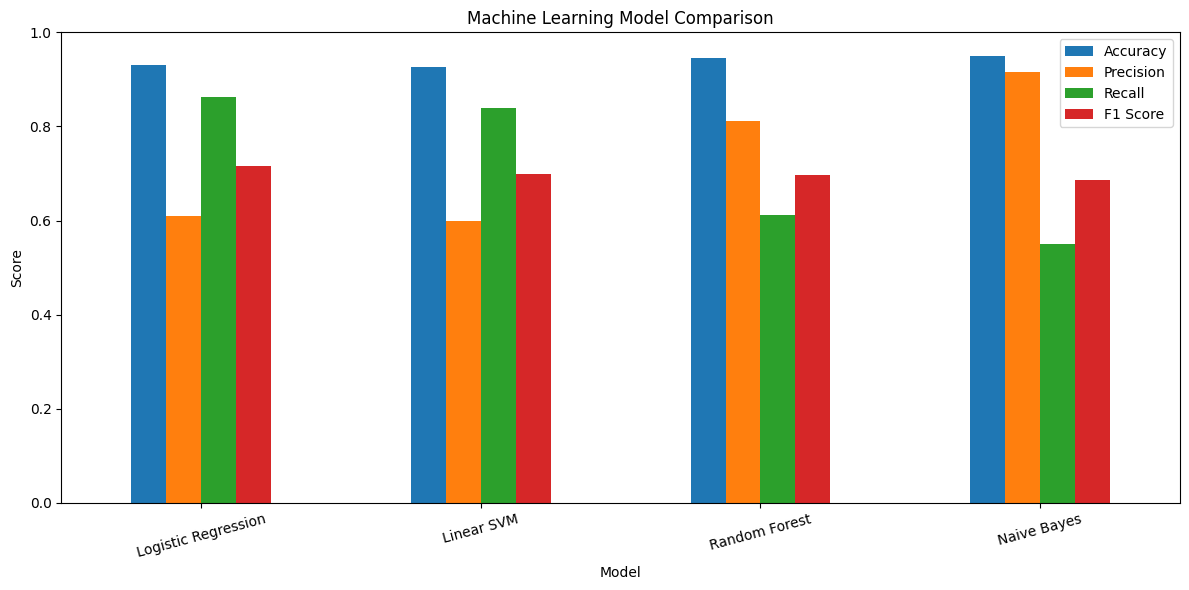

In [13]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

ax = results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Machine Learning Model Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Detailed evaluation of the best model

The project selects the model with the highest **F1 score**, rather than simply choosing the highest accuracy. This is more appropriate for the imbalanced target because accuracy alone can hide poor minority-class detection.

In [14]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

best_pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    best_pred,
    target_names=["Non-Toxic", "Toxic"],
    zero_division=0
))

Best model: Logistic Regression
              precision    recall  f1-score   support

   Non-Toxic       0.98      0.94      0.96     28670
       Toxic       0.61      0.86      0.71      3245

    accuracy                           0.93     31915
   macro avg       0.80      0.90      0.84     31915
weighted avg       0.95      0.93      0.94     31915



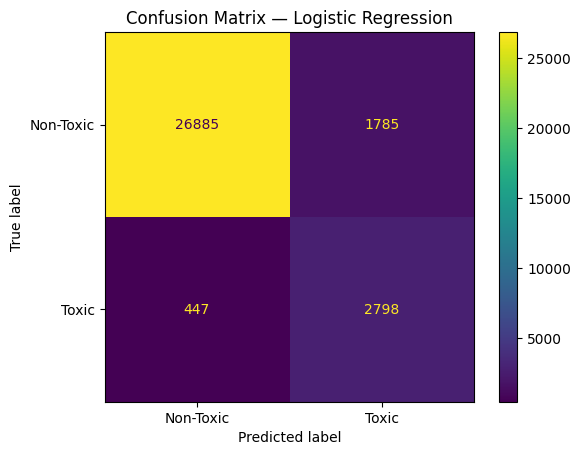

In [15]:
cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Toxic", "Toxic"]
)
disp.plot()
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## 8. Mounting Drive

In [16]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import os

model_path = "/content/drive/MyDrive/Toxicity_Hate_Speech_Project/Models/"

os.makedirs(model_path, exist_ok=True)

print("Model directory:")
print(model_path)

Model directory:
/content/drive/MyDrive/Toxicity_Hate_Speech_Project/Models/


In [18]:
import pickle

model_file = os.path.join(model_path, "best_model.pkl")

with open(model_file, "wb") as f:
    pickle.dump(best_model, f)

print("✅ Best model saved successfully!")
print(model_file)

✅ Best model saved successfully!
/content/drive/MyDrive/Toxicity_Hate_Speech_Project/Models/best_model.pkl


In [19]:
vectorizer_file = os.path.join(
    model_path,
    "tfidf_vectorizer.pkl"
)

with open(vectorizer_file, "wb") as f:
    pickle.dump(vectorizer, f)

print("✅ TF-IDF vectorizer saved successfully!")
print(vectorizer_file)

✅ TF-IDF vectorizer saved successfully!
/content/drive/MyDrive/Toxicity_Hate_Speech_Project/Models/tfidf_vectorizer.pkl


In [20]:
print("Files in model directory:")

for file in os.listdir(model_path):
    print("✔", file)

Files in model directory:
✔ best_model.pkl
✔ tfidf_vectorizer.pkl


In [21]:
with open(
    os.path.join(model_path, "best_model.pkl"),
    "rb"
) as f:
    loaded_model = pickle.load(f)

with open(
    os.path.join(model_path, "tfidf_vectorizer.pkl"),
    "rb"
) as f:
    loaded_vectorizer = pickle.load(f)

print("✅ Model loaded successfully!")
print("✅ Vectorizer loaded successfully!")

✅ Model loaded successfully!
✅ Vectorizer loaded successfully!


In [22]:
# ==========================================
# TOXICITY PREDICTION FUNCTION
# ==========================================

def predict_toxicity(text):

    # Clean the input text
    cleaned_text = clean_text(text)

    # Convert text into TF-IDF features
    vectorized_text = loaded_vectorizer.transform(
        [cleaned_text]
    )

    # Get prediction
    prediction = loaded_model.predict(
        vectorized_text
    )[0]

    # Get probabilities
    probabilities = loaded_model.predict_proba(
        vectorized_text
    )[0]

    non_toxic_probability = probabilities[0]
    toxic_probability = probabilities[1]

    # Convert prediction into label
    if prediction == 1:
        result = "TOXIC"
    else:
        result = "NON-TOXIC"

    return result, non_toxic_probability, toxic_probability

In [ ]:
# ==========================================
# CUSTOM COMMENT DETECTOR
# ==========================================

custom_query = input("Enter a comment: ")

result, non_toxic_prob, toxic_prob = predict_toxicity(custom_query)

print("\n" + "=" * 55)
print("              TOXICITY DETECTION")
print("=" * 55)

print("COMMENT :", custom_query)
print("RESULT  :", result)

print(f"Non-Toxic Probability : {non_toxic_prob * 100:.2f}%")
print(f"Toxic Probability     : {toxic_prob * 100:.2f}%")

print("=" * 55)